      altitude  temperature       pressure       density
0            0   288.149994  101324.996948  1.224977e+00
1           10   288.068756  101174.926758  1.223508e+00
2           20   287.987488  101025.032043  1.222040e+00
3           30   287.906250  100875.320435  1.220573e+00
4           40   287.824982  100725.784302  1.219108e+00
...        ...          ...            ...           ...
6995     69950   186.945999       0.000089  1.666039e-09
6996     69960   186.945999       0.000057  1.067306e-09
6997     69970   186.945999       0.000032  6.009021e-10
6998     69980   186.945999       0.000014  2.668266e-10
6999     69990   186.945999       0.000003  6.507965e-11

[7000 rows x 4 columns]


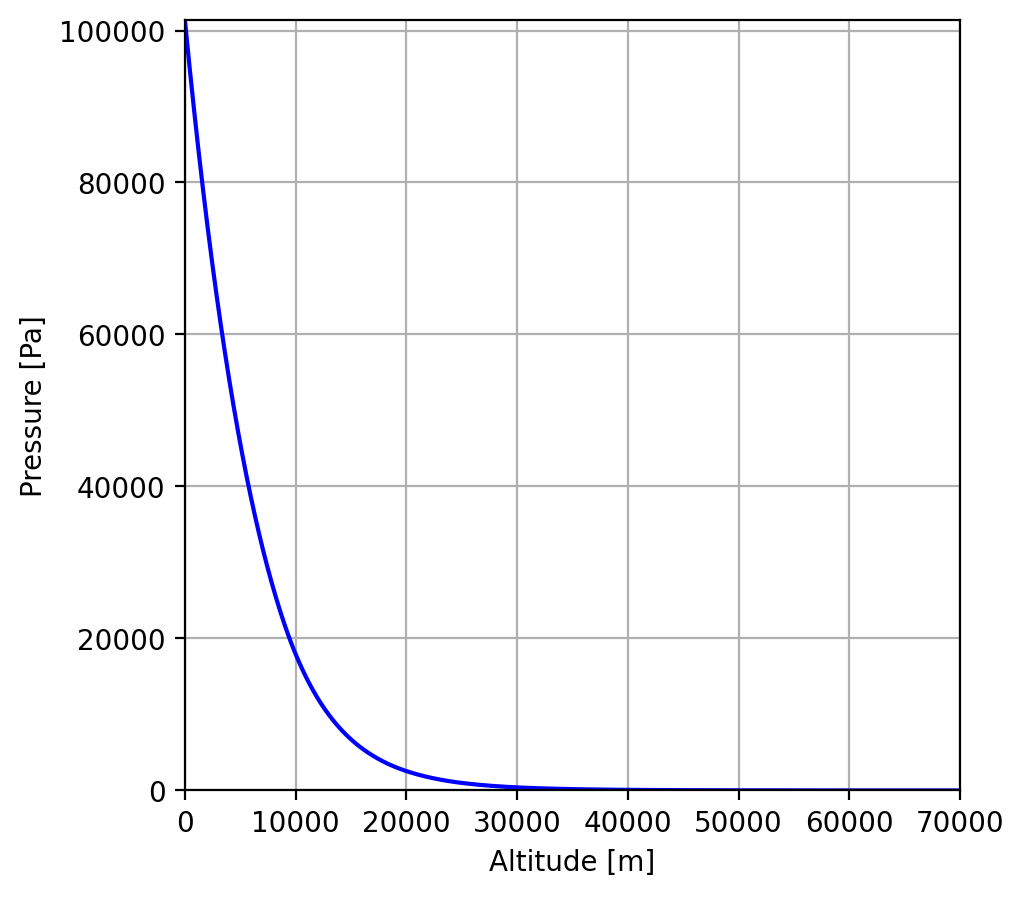

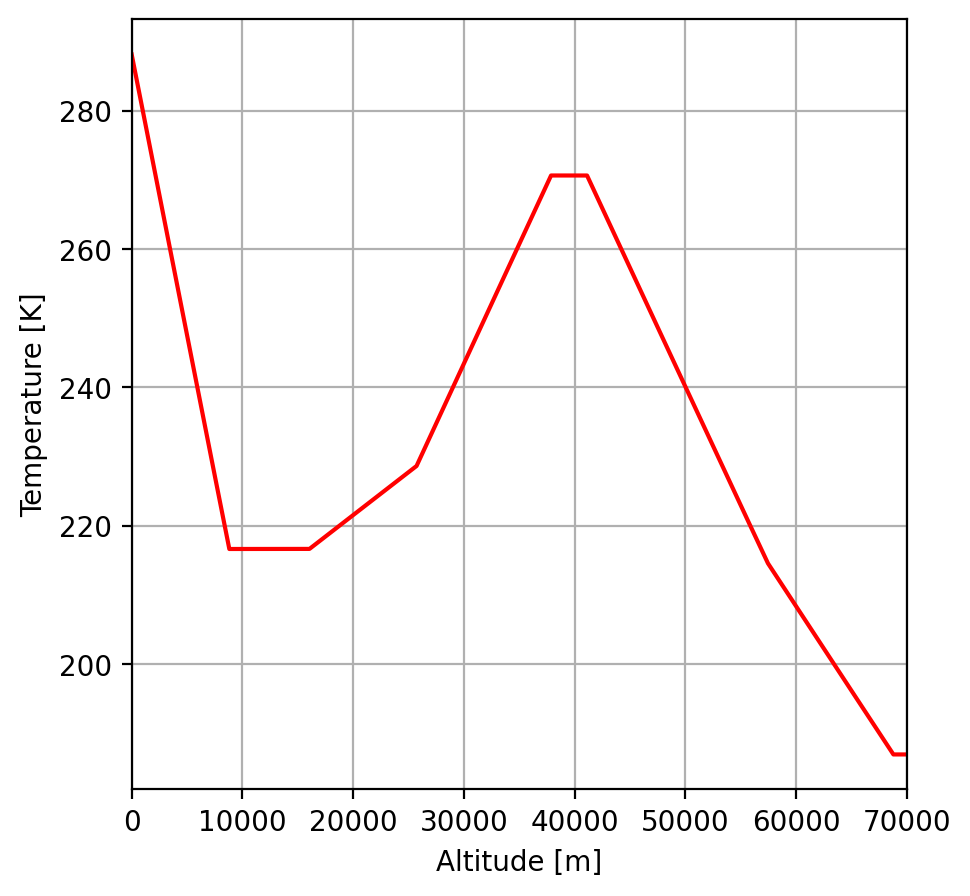

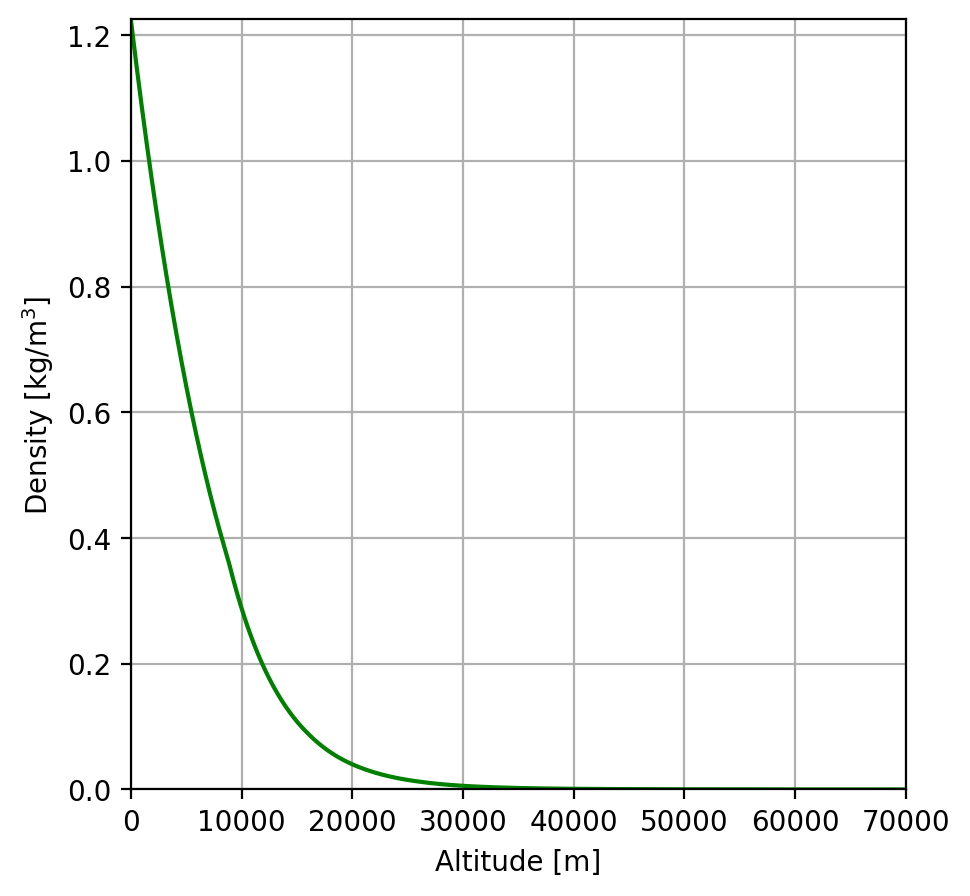

In [54]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np 


df = pd.read_csv('atmdata_kerbin.csv')
print(df)

plt.figure(figsize=(5,5),dpi=200)
plt.plot(df['altitude'],df['pressure'],'b-')
plt.xlabel("Altitude [m]")
plt.ylabel("Pressure [Pa]")
plt.xlim(0,70000)
plt.ylim(0,101325)
plt.grid()
plt.show()

plt.figure(figsize=(5,5),dpi=200)
plt.plot(df['altitude'],df['temperature'],'r-')
plt.xlabel("Altitude [m]")
plt.ylabel("Temperature [K]")
plt.xlim(0,70000)
plt.grid()
plt.show()

plt.figure(figsize=(5,5),dpi=200)
plt.plot(df['altitude'],df['density'],'g-')
plt.xlabel("Altitude [m]")
plt.ylabel("Density [kg/m$^3$]")
plt.xlim(0,70000)
plt.ylim(0,1.225)
plt.grid()
plt.show()

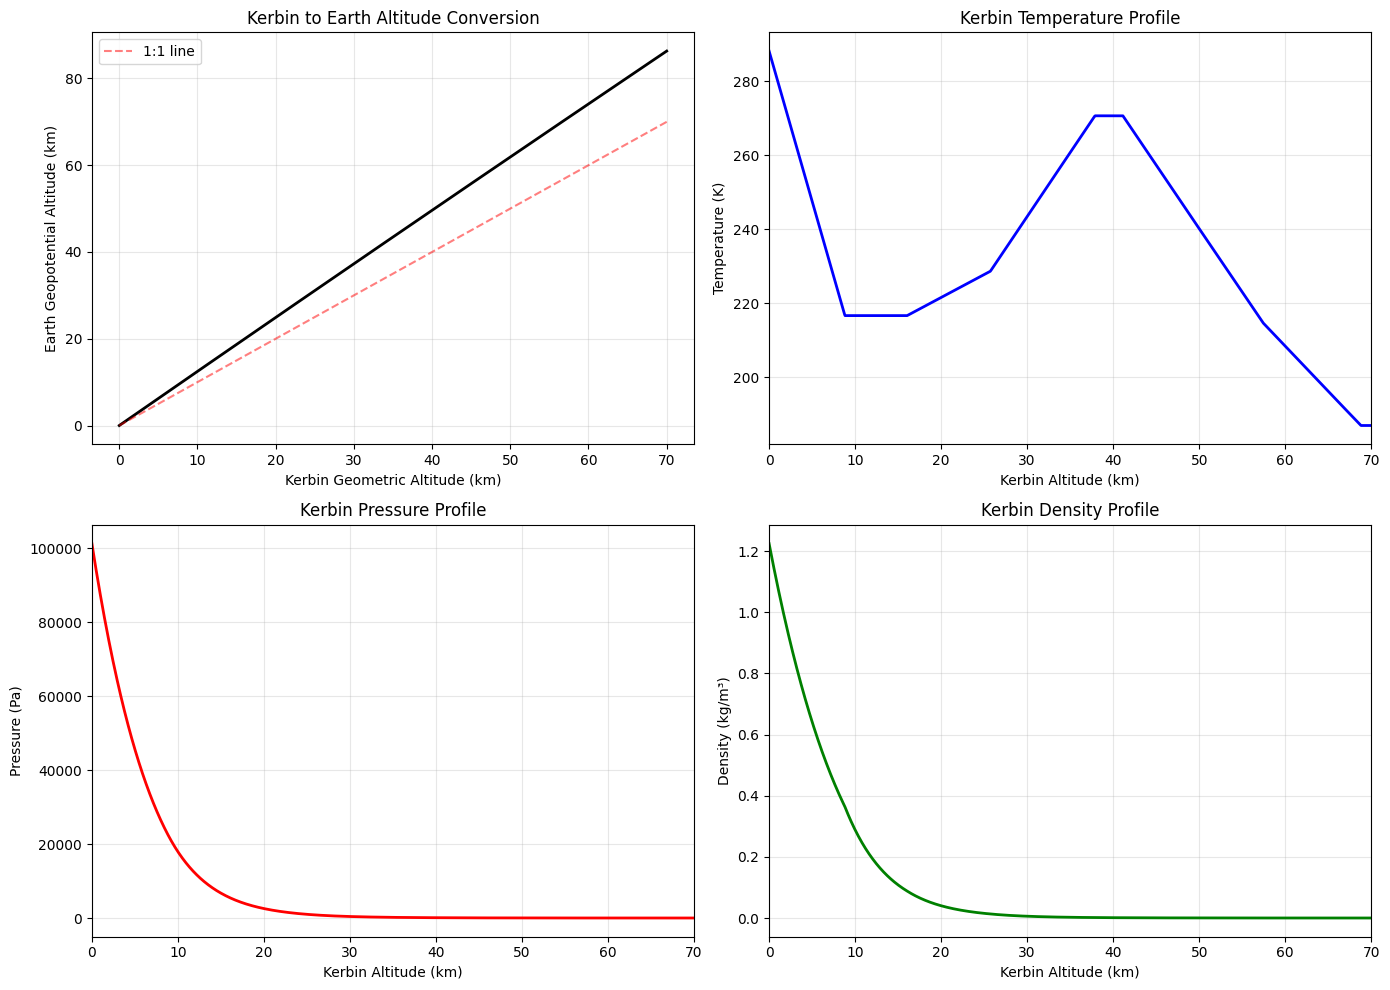


Kerbin Atmosphere Model (Scaled from USSA)
Kerbin Alt (km) Earth Alt (km)  Temp (K)     Pressure (Pa)   Density (kg/m³)
----------------------------------------------------------------------
0.000           0.000           288.15       101325.00       1.224999       
5.000           6.244           247.56       45624.51        0.642018       
10.000          12.476          216.65       17933.93        0.288373       
15.000          18.695          216.65       6725.85         0.108150       
20.000          24.902          221.55       2549.14         0.040083       
30.000          37.281          243.44       404.11          0.005783       
40.000          49.611          270.65       79.77           0.001027       
50.000          61.893          240.15       15.56           0.000226       
60.000          74.127          208.40       2.39            0.000040       
70.000          86.315          186.95       0.00            0.000000       

Sea Level Verification:
Temperature a

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
R = 287.053
def kerbin_atmosphere(z):
    """
    Kerbin atmosphere model (scaled from 1976 US Standard Atmosphere)
    z: altitude in kilometers on Kerbin (0 to ~70 km)
    returns: temperature (K), pressure (Pa), density (kg/m³)
    """
    
    # Constants
    R = 287.053  # J/(kg·K) - specific gas constant for dry air
    
    # Convert Kerbin geometric altitude to Earth geopotential altitude
    # h = (7963.75 * z) / (6371 + 1.25 * z)
    # where z is Kerbin geometric altitude in km
    # h is Earth geopotential altitude in km
    h = (7963.75 * z) / (6371 + 1.25 * z)
    
    # Now use Earth's USSA model with converted altitude
    if h < 11:
        # Troposphere: 0-11 km
        T = 288.15 - 6.5 * h
        P = 101325.0 * (288.15 / (288.15 - 6.5 * h)) ** (34.1632 / -6.5)
        
    elif h < 20:
        # Stratosphere part 1: 11-20 km
        T = 216.65
        P = 22632.06 * np.exp(-34.1632 * (h - 11) / 216.65)
        
    elif h < 32:
        # Stratosphere part 2: 20-32 km
        T = 196.65 + h
        P = 5474.889 * (216.65 / (216.65 + (h - 20))) ** (34.1632)
        
    elif h < 47:
        # Stratosphere part 3: 32-47 km
        T = 139.05 + 2.8 * h
        P = 868.0187 * (228.65 / (228.65 + 2.8 * (h - 32))) ** (34.1632 / 2.8)
        
    elif h < 51:
        # Mesosphere part 1: 47-51 km
        T = 270.65
        P = 110.9063 * np.exp(-34.1632 * (h - 47) / 270.65)
        
    elif h < 71:
        # Mesosphere part 2: 51-71 km
        T = 413.45 - 2.8 * h
        P = 66.93887 * (270.65 / (270.65 - 2.8 * (h - 51))) ** (34.1632 / -2.8)
        
    elif h <= 84.852:
        # Mesosphere part 3: 71-84.852 km
        T = 356.65 - 2.0 * h
        P = 3.956420 * (214.65 / (214.65 - 2 * (h - 71))) ** (34.1632 / -2)
        
    else:
        # Extrapolate for h > 84.852 km (for Kerbin altitudes above ~70km)
        T = 186.946  # Approximate
        P = 0.003956 * np.exp(-34.1632 * (h - 84.852) / 186.946)
    
    # Calculate density using ideal gas law
    rho = P / (R * T)
    
    return T, P, rho

# Vectorize the function for array inputs
kerbin_atmosphere_vec = np.vectorize(kerbin_atmosphere, signature='()->(),(),()')

# Test and plot for Kerbin altitudes
z_test = np.linspace(0, 70, 1000)  # Kerbin altitude range (0-70km)
T_test, P_test, rho_test = kerbin_atmosphere_vec(z_test)

# Create altitude conversion plot
h_test = (7963.75 * z_test) / (6371 + 1.25 * z_test)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Altitude conversion
axes[0, 0].plot(z_test, h_test, 'k-', linewidth=2)
axes[0, 0].set_xlabel('Kerbin Geometric Altitude (km)')
axes[0, 0].set_ylabel('Earth Geopotential Altitude (km)')
axes[0, 0].set_title('Kerbin to Earth Altitude Conversion')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].plot([0, 70], [0, 70], 'r--', alpha=0.5, label='1:1 line')
axes[0, 0].legend()

# Temperature profile
axes[0, 1].plot(z_test, T_test, 'b-', linewidth=2)
axes[0, 1].set_xlabel('Kerbin Altitude (km)')
axes[0, 1].set_ylabel('Temperature (K)')
axes[0, 1].set_title('Kerbin Temperature Profile')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlim(0, 70)

# Pressure profile
axes[1, 0].plot(z_test, P_test, 'r-', linewidth=2)
axes[1, 0].set_xlabel('Kerbin Altitude (km)')
axes[1, 0].set_ylabel('Pressure (Pa)')
axes[1, 0].set_title('Kerbin Pressure Profile')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlim(0, 70)

# Density profile
axes[1, 1].plot(z_test, rho_test, 'g-', linewidth=2)
axes[1, 1].set_xlabel('Kerbin Altitude (km)')
axes[1, 1].set_ylabel('Density (kg/m³)')
axes[1, 1].set_title('Kerbin Density Profile')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim(0, 70)

plt.tight_layout()
plt.show()

# Print values at key altitudes
print("\nKerbin Atmosphere Model (Scaled from USSA)")
print("="*70)
print(f"{'Kerbin Alt (km)':<15} {'Earth Alt (km)':<15} {'Temp (K)':<12} {'Pressure (Pa)':<15} {'Density (kg/m³)':<15}")
print("-"*70)

for z in [0, 5, 10, 15, 20, 30, 40, 50, 60, 70]:
    h = (7963.75 * z) / (6371 + 1.25 * z)
    T, P, rho = kerbin_atmosphere(z)
    print(f"{z:<15.3f} {h:<15.3f} {T:<12.2f} {P:<15.2f} {rho:<15.6f}")

# Verify sea level conditions
print("\n" + "="*70)
print("Sea Level Verification:")
T0, P0, rho0 = kerbin_atmosphere(0)
print(f"Temperature at sea level: {T0:.2f} K ({T0-273.15:.2f}°C)")
print(f"Pressure at sea level: {P0:.2f} Pa ({P0/1000:.3f} kPa)")
print(f"Density at sea level: {rho0:.6f} kg/m³")

# Calculate scale height approximation
h_scale_approx = R * T0 / 9.81
print(f"\nApproximate scale height at sea level: {h_scale_approx/1000:.2f} km") 